In [42]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [12]:
with open("music_samples.txt", 'r') as file:
    lines = file.readlines()

signal = np.array([float(element) for element in lines])
frequency = 44100
duration = len(signal) / frequency
times = np.linspace(0, duration, len(lines))


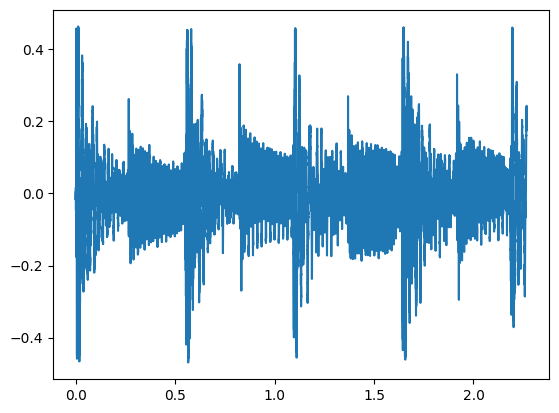

In [13]:
plt.plot(times, signal)

In [67]:
bpm = 110
bps = bpm / 60
n_beats = duration * bps
n_eights = n_beats * 2
seg_length = int(len(signal) / n_eights)

print(seg_length)

12027


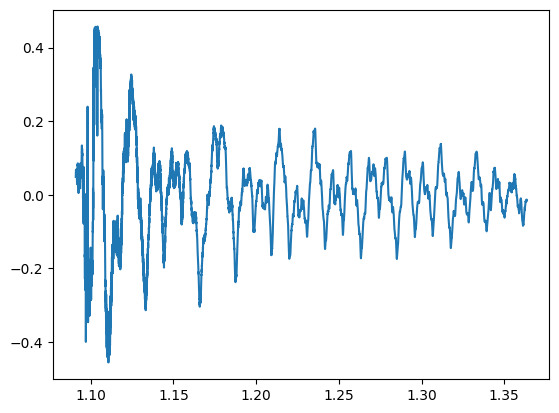

In [160]:
n_seg = 4
seg = signal[n_seg*seg_length:(n_seg+1)*seg_length]
plt.plot(times[n_seg*seg_length:(n_seg+1)*seg_length], seg)

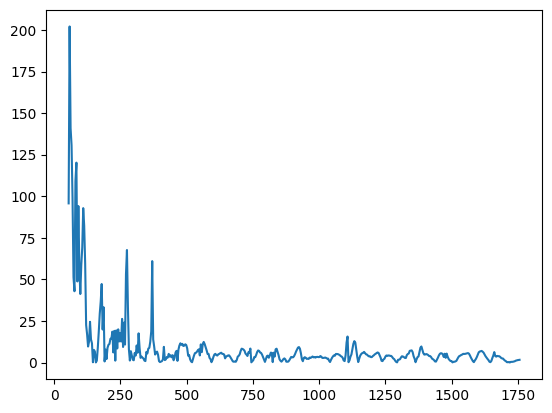

In [172]:
fourier = np.fft.fft(seg)
fourier = np.abs(np.real(fourier))
freqs = np.fft.fftfreq(seg.shape[-1]) * frequency

# Limit to positive values
fourier = fourier[:int(len(fourier)/2)]
freqs = freqs[:int(len(freqs)/2)]

# Limit to 5-octave range to eliminate weird stuff from percussion
start = np.searchsorted(freqs, 55, "left")
end = np.searchsorted(freqs, 1760, "right")
fourier = fourier[start:end]
freqs = freqs[start:end]

plt.plot(freqs, fourier)

In [173]:
peaks, properties = sp.signal.find_peaks(fourier, height=10, distance=6.7)
peak_freqs = freqs[peaks]
order = np.argsort(properties['peak_heights'])[::-1]
peak_freqs = peak_freqs[order]

In [174]:
def freq_to_note(freq):
    names = [
        "C", "C#", "D", "Eb", "E", "F", "F#", "G", "Ab", "A", "Bb", "B"
    ]
    A4 = 440.0
    C0 = A4 * (2 ** -4.75)

    h = np.round(12 * np.log2(freq / C0))
    octave = int(h // 12)
    note = int(h % 12)

    return names[note] + str(octave)

In [171]:
notes = [freq_to_note(freq) for freq in peak_freqs]
print(notes[:10])

[]
